# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Gonzaga, Thomas
- _Student No._: 2023-16222
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.


### Report discussion

WHY CANT BISECTION METHOD SOLVE FOR THE MIDDLE ROOT

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- Refer to `Bruh What.jpg`


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

<function matplotlib.pyplot.show(close=None, block=None)>

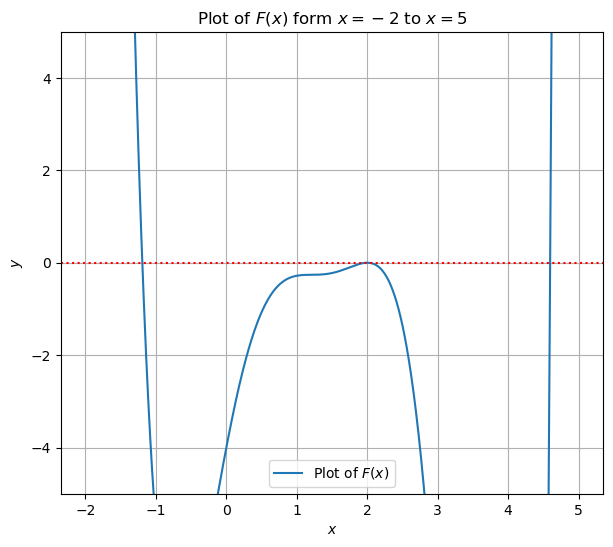

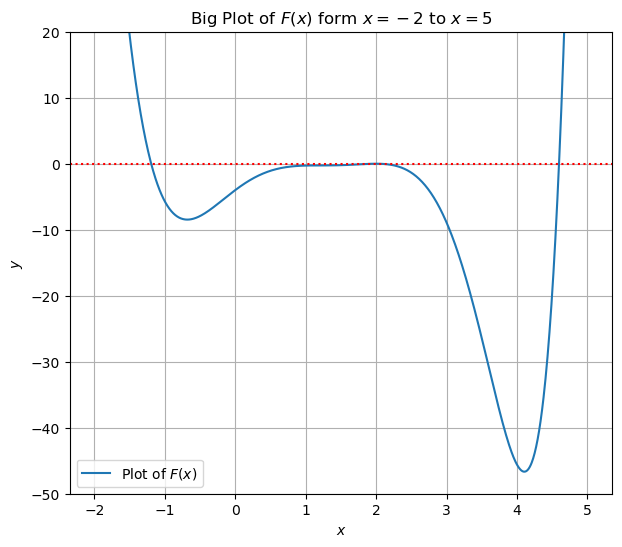

In [26]:
# Code for plot, just defining the funciton for future use

def f(x):
    return -(x**5) + 4*(x**4) - 4*(x**3) + (x**2)*np.exp(x) - 2*(x**2) - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

# my first derivation was causing issues, simplified it further 
def df(x):
    return -(5*x**4) + 16*(x**3) - 12*(x**2) + (2*x*np.exp(x) + (x**2)*np.exp(x)) - 4*x + 8 + 4*np.exp(x)

x_vals = np.linspace(-2, 5, 1000)
y_vals = f(x_vals)

# plotting f(x)
plt.figure(figsize=(7, 6))
plt.plot(x_vals, y_vals, label='Plot of $F(x)$')
plt.axhline(0, color='red', linestyle=':')
plt.ylim(-5, 5)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Plot of $F(x)$ form $x=-2$ to $x=5$')
plt.grid()
plt.legend()
plt.show

plt.figure(figsize=(7, 6))
plt.plot(x_vals, y_vals, label='Plot of $F(x)$')
plt.axhline(0, color='red', linestyle=':')
plt.ylim(-50, 20)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Big Plot of $F(x)$ form $x=-2$ to $x=5$')
plt.grid()
plt.legend()
plt.show

In [27]:
# Root Finding Methods
##################################################

# Fixed Point Method, main ref from gerzelis code 5.1

def f(x):
    return np.exp(x - np.sqrt(x))

def fixedpoint(f, xold, kmax=200, tol=1.e-8):
    # history tracks and stores the steps of the root finding process
    history = [xold]
    x = xold
    for i in range(kmax):
        xnew = f(x)

        history.append(xnew)

        xdiff = xnew - x

        if abs(xdiff/xnew) < tol:
            break
            
        x = xnew # update current x for next iteration
        
    else:
        xnew = None
    # allows us to plot the data
    return np.array(history)

In [28]:
# Bisection Method

def f(x):
    return np.exp(x - np.sqrt(x)) - x

def bisection(h, x0, x1, kmax=200, tol=1.e-8):
    # holds our data
    history = []
    
    for i in range(kmax):
        # takes both guesses and divides them by half, meeting in the middle
        x2 = (x0 + x1)/2
        # keeps track of our data
        history.append(x2)
        # stops the code from running indefinitley
        if abs(f(x2)) < tol or abs(x1 - x0) / 2.0 < tol:
            break
        # if our new calculated midpoint is basically very close to our previous guess, the code stops and calls that our root
        if f(x2) * f(x0) < 0:
            x1 = x2
        else:
        # same thing but applies it to the other bound if it isnt close enough
            x0 = x2
    # allows us to plot the data
    return np.array(history)

In [29]:
# Newton Method
def newton(f, df, x0, kmax=200, tol=1e-8):
    history = [x0]
    x = x0
    for i in range(kmax):
    
        f_val = f(x)
        df_val = df(x)
        if df_val == 0:
            break
        x_next = x - f_val / df_val
        # adds our new x value to be used for future iteration
        history.append(x_next)
        if abs(x_next - x) < tol:
            break
        x = x_next
    return np.array(history)

In [30]:
# Secant Method
def secant(f, x0, x1, kmax=200, tol=1e-8):
    history = [x0, x1]
    for _ in range(kmax):
        f_x0 = f(history[-2])
        f_x1 = f(history[-1])
        if f_x1 - f_x0 == 0:
            break
        x_next = history[-1] - f_x1 * (history[-1] - history[-2]) / (f_x1 - f_x0)
        history.append(x_next)
        if abs(x_next - history[-2]) < tol:
            break
    return np.array(history)

In [31]:
# for fixed point at f(x) = 0
# derived 
def fixed(x):
    return (-f(x) + 8*x) / 8.0

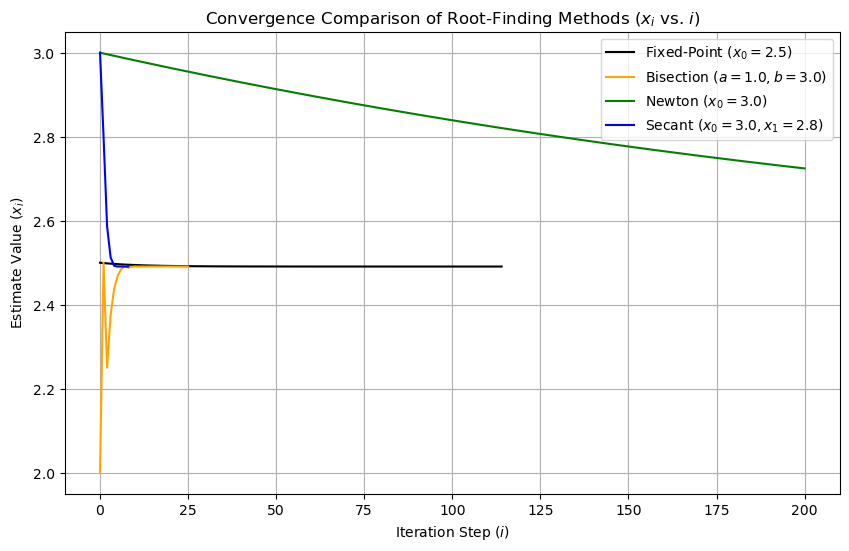

In [32]:
# Plotting
# this is where we plug in values
hist_fixed = fixedpoint(fixed, xold=2.5) # xold is our initial guess
hist_bisect = bisection(f, x0=1.0, x1= 3.0) # x0 and x1 are the bounds
hist_newton = newton(f, df, x0=3.0) # x0 is the initial guess
hist_secant = secant(f, x0=3.0, x1=2.8) # x0 and x1 are both initial guesses

plt.figure(figsize=(10, 6))
plt.plot(range(len(hist_fixed)), hist_fixed,label=r'Fixed-Point ($x_0=2.5$)', color='black')
plt.plot(range(len(hist_bisect)), hist_bisect, label=r'Bisection ($a=1.0, b=3.0$)', color='orange')
plt.plot(range(len(hist_newton)), hist_newton, label=r'Newton ($x_0=3.0$)', color='green')
plt.plot(range(len(hist_secant)), hist_secant, label=r'Secant ($x_0=3.0, x_1=2.8$)', color='blue')

plt.title('Convergence Comparison of Root-Finding Methods ($x_i$ vs. $i$)')
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimate Value ($x_i$)')
plt.grid(True)
plt.legend()
plt.show()

In [33]:
# present thing root values cuz idk what i was doing

root_fixed  = hist_fixed[-1]
root_bisect = hist_bisect[-1]
root_newton = hist_newton[-1]
root_secant = hist_secant[-1]

print(f"Fixed-Point Root: {root_fixed:.6f}")
print(f"Bisection Root:   {root_bisect:.6f}")
print(f"Newton's Root:    {root_newton:.6f}")
print(f"Secant Root:      {root_secant:.6f}")

Fixed-Point Root: 2.490910
Bisection Root:   2.490909
Newton's Root:    2.724535
Secant Root:      2.490909


#### Problem 1 code summary

The first part of the code presents our function and confirms that we have 3 roots. Next we define our 4 methods and put their collected data in an array for easier plotting. Finally the data was compiled and plotted on a single graph.

---